dict_keys(['Iter', 'L', 'LE', 'LF', 'Time'])
(20001, 5)


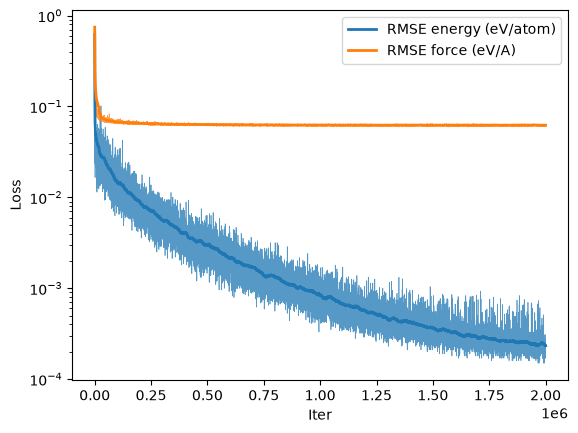

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def parse_line(line):
    tokens = line.split() #line.split()  Split the line into tokens
    data = {}
    i = 0
    while i < len(tokens):
        key = tokens[i]
        value = tokens[i + 1]

        # Remove trailing 's' from Time
        if value.endswith('s'):
            value = value[:-1]

        # Try to convert to int or float
        try:
            if '.' in value:
                value = float(value)
            else:
                value = int(value)
        except ValueError:
            pass

        data[key] = value
        i += 2 #esto es porque cada par de tokens es un key y un value, entonces se incrementa en 2 para pasar al siguiente par

    return data

results = []
with open("./log.txt") as f:
    for line in f:
        if line.startswith("Iter"):
            results.append(parse_line(line)) #la salida es una lista de diccionarios, donde cada diccionario contiene los datos de una línea del log

keys = results[0].keys()
array = np.array([[row[k] for k in keys] for row in results])

print(keys)
print(array.shape)

def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out

everyN=1
window = 200

colors = ['C0', 'C1']
x = array[::everyN, 0]
y1 = array[::everyN, 2]
y2 = array[::everyN, 3]
y1_avg = running_avg(y1, window)
y2_avg = running_avg(y2, window)
plt.plot(x, y1,color=colors[0],alpha=0.75, linewidth=0.5)
plt.plot(x, y2,color=colors[1],alpha=0.75, linewidth=0.5)
plt.plot(x, y1_avg, label="RMSE energy (eV/atom)",color=colors[0], linewidth=2)
plt.plot(x, y2_avg, label="RMSE force (eV/A)",color=colors[1], linewidth=2)
plt.xlabel("Iter")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [24]:
# forces = np.load("/scratch/vperez/ForVera/CaCO3-SCAN-ML/training-set/water/set.000/force.npy")
# plt.hist(forces, bins=50, density=True, alpha=0.5, color='C1', label='Force Distribution')
# plt.xlabel('Force (eV/A)')
# plt.ylabel('Density')
# plt.title('Force Distribution Histogram for Water')
# plt.legend()
# plt.show() 

In [25]:
# forces = np.load("/scratch/vperez/ForVera/CaCO3-SCAN-ML/training-set/caco3/set.000/force.npy")
# plt.hist(forces, bins=50, density=True, alpha=0.5, color='C1', label='Force Distribution')
# plt.xlabel('Force (eV/A)')
# plt.ylabel('Density')
# plt.title('Force Distribution Histogram for CaCO3')
# plt.legend()
# plt.show() 

In [26]:
# energy = np.load("/scratch/vperez/ForVera/CaCO3-SCAN-ML/training-set/caco3/set.000/energy.npy")
# plt.hist(energy, bins=50, density=True, alpha=0.5, color='C0', label='Energy Distribution')
# plt.xlabel('Energy (eV)')
# plt.ylabel('Density')
# plt.title('Energy Distribution Histogram for CaCO3')
# plt.legend()
# plt.show() 

PREDICCIONES, PARITY PLOTS

In [27]:
results_energy = []
with open("./pred_energy.txt") as f:
    for line in f:
        if line.startswith("Elemento"):
            results_energy.append(parse_line(line)) #la salida es una lista de diccionarios, donde cada diccionario contiene los datos de una línea del log

keys = results_energy[0].keys()
df_energy=pd.DataFrame(results_energy)
array_energy = df_energy.to_numpy()

print(keys)
print(array_energy.shape)

dict_keys(['Elemento', 'Pred_Energy', 'True_Energy'])
(16091, 3)


['4caco3' 'ca' 'caco3' 'caco3-protonation' 'co3' 'cryst-iceIc'
 'cryst-iceIh' 'water']


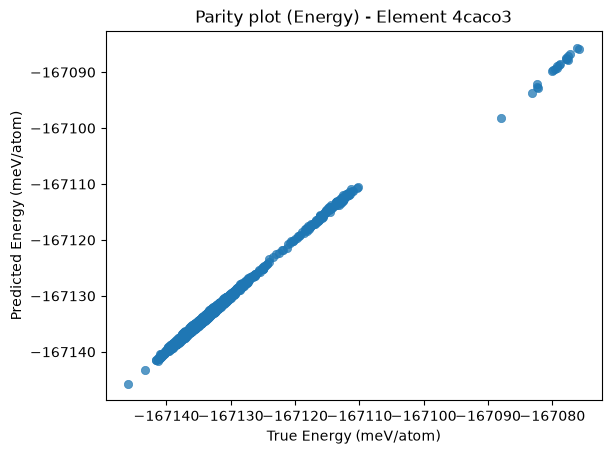

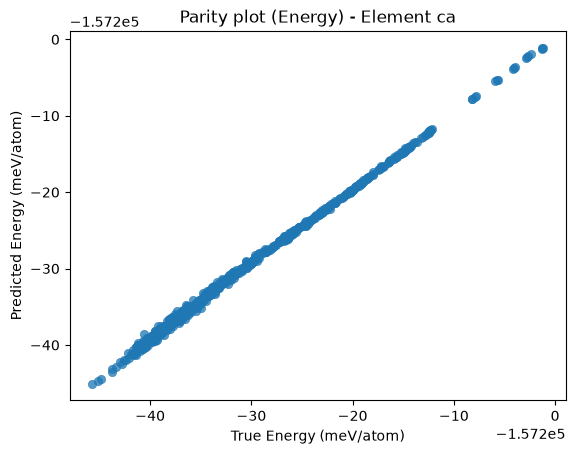

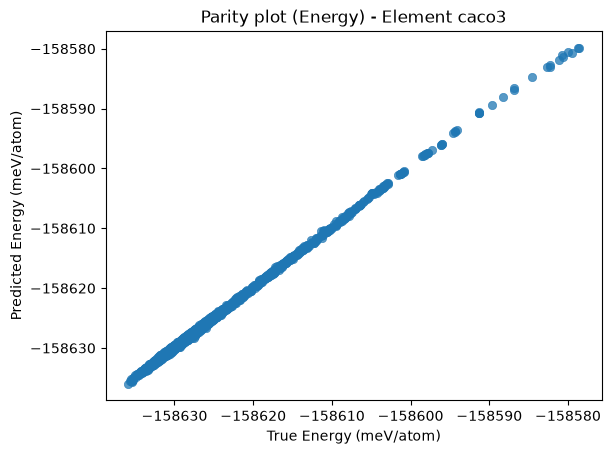

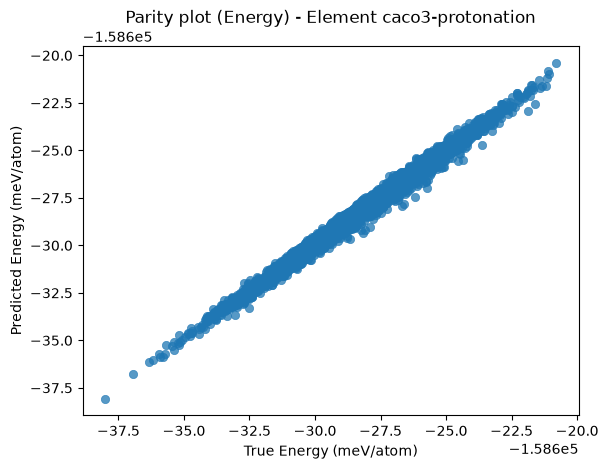

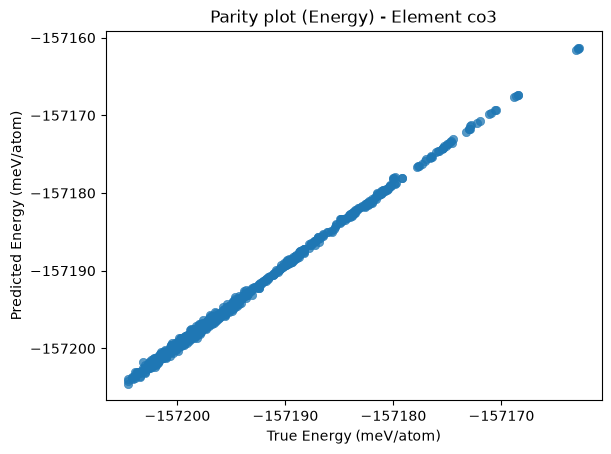

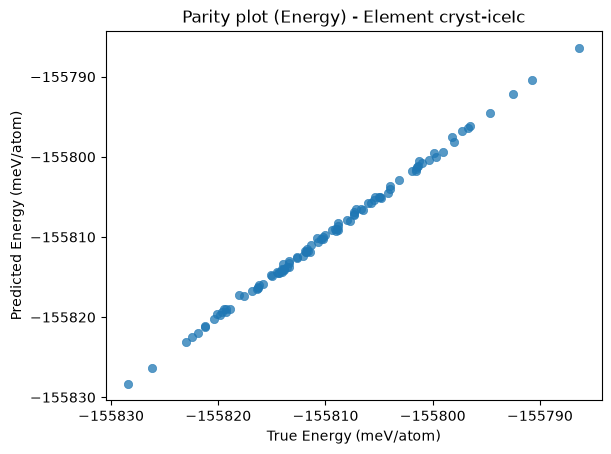

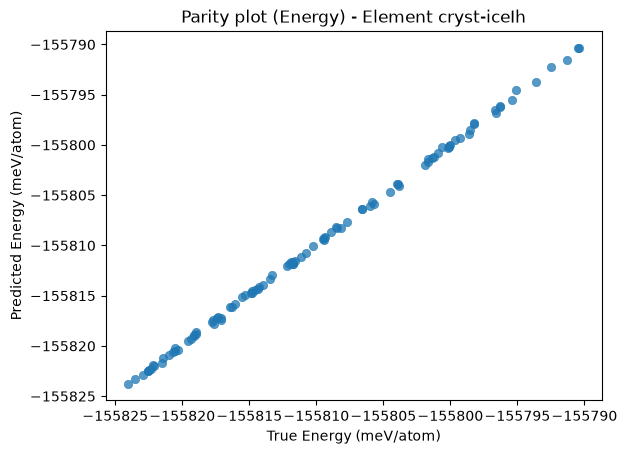

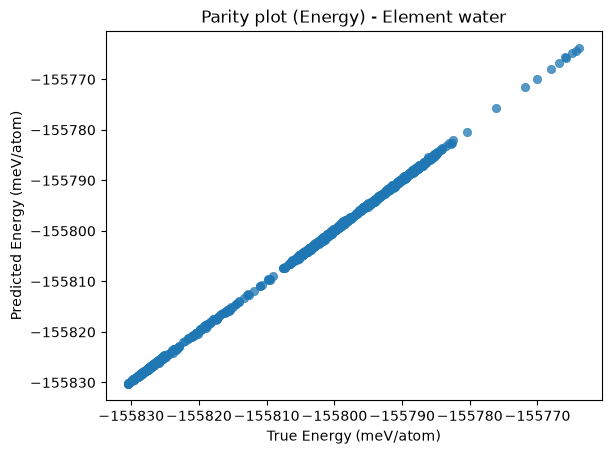

In [28]:
#PARTIY PLOTS Energía

colors = ['C0', 'C1']
rmse_energy_list = []
array_elementos = np.unique(array_energy[:, 0])
print(array_elementos)
for elemento in array_elementos:
    array_elemento = array_energy[array_energy[:, 0] == elemento]
    x1=array_elemento[:, 2].astype(float)
    y1=array_elemento[:, 1].astype(float)

    #Calcular el RMSE para Energy
    rmse_energy = np.sqrt(np.mean(np.power(y1-x1,2)))
    rmse_energy_list.append(rmse_energy)

    #PARITY PLOTS
    plt.figure()
    plt.scatter(x1, y1, color=colors[0], alpha=0.75, linewidth=0.5)
    plt.xlabel("True Energy (meV/atom)")
    plt.ylabel("Predicted Energy (meV/atom)")
    plt.title(f"Parity plot (Energy) - Element {elemento}")

In [29]:
#leo los resultados de la fuerza

results_force = []
rmse_force_list = []
with open("./pred_force.txt") as f:
    for i, line in enumerate(f):
         if line.startswith("RMSE_Elemento"):
            tokens = line.split()
            rmse_force = float(tokens[-1])
            rmse_force_list.append(rmse_force)
         else:         
            if i % 10 !=0:
                    continue
            else:
                if line.startswith("Elemento"):
                    results_force.append(parse_line(line)) #la salida es una lista de diccionarios, donde cada diccionario contiene los datos de una línea del log

keys = results_force[0].keys()
df_force=pd.DataFrame(results_force)
array_force=df_force.to_numpy()

print(keys)
print(array_force.shape)
print(rmse_force_list)

#comproblamos si los elementos de array_energy y array_force son los mismos
print(np.unique(array_force[:, 0]) == array_elementos)

dict_keys(['Elemento', 'Pred_Force', 'True_Force'])
(2954855, 3)
[92.9283, 87.7198, 87.4598, 89.569, 86.654, 88.6964, 79.1759, 86.3295]
[ True  True  True  True  True  True  True  True]


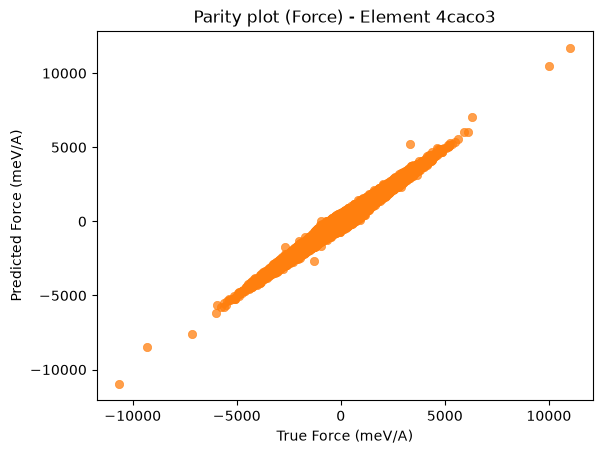

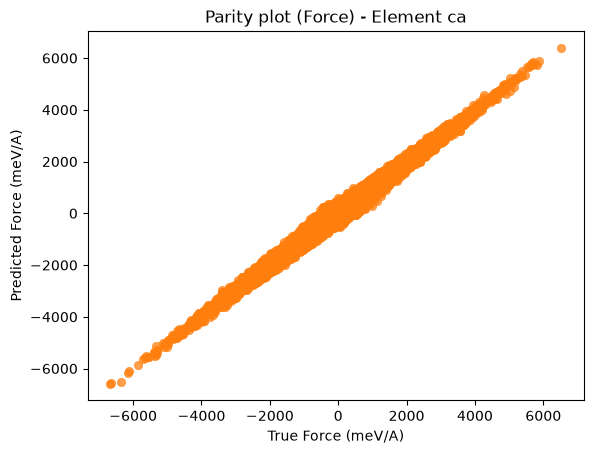

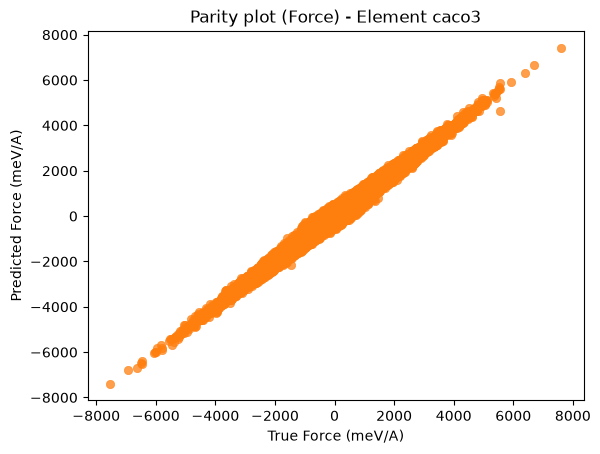

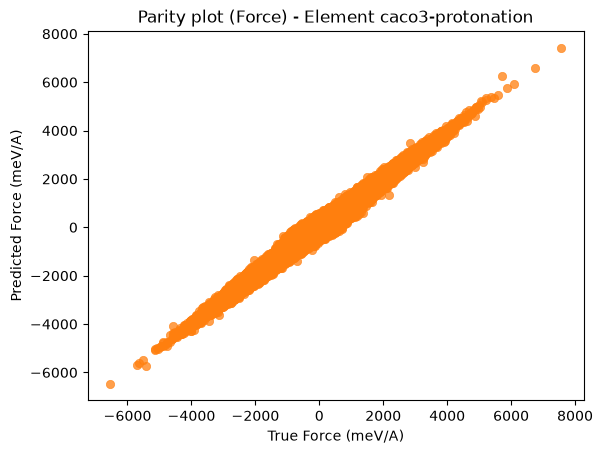

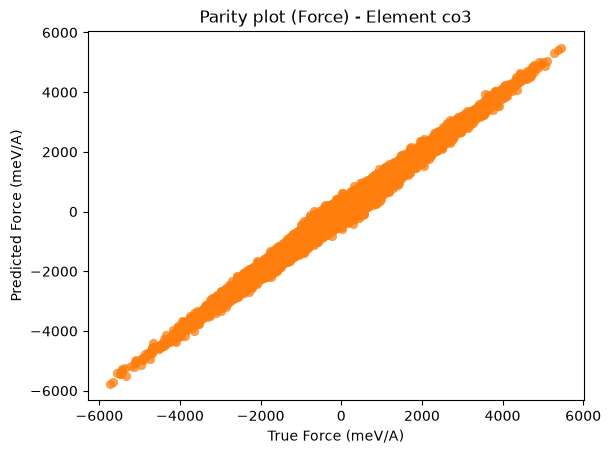

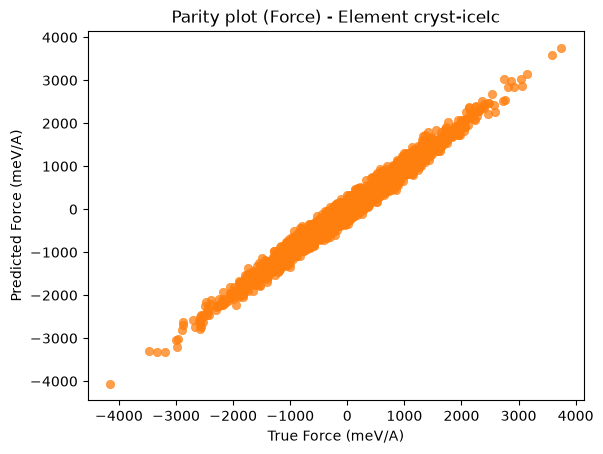

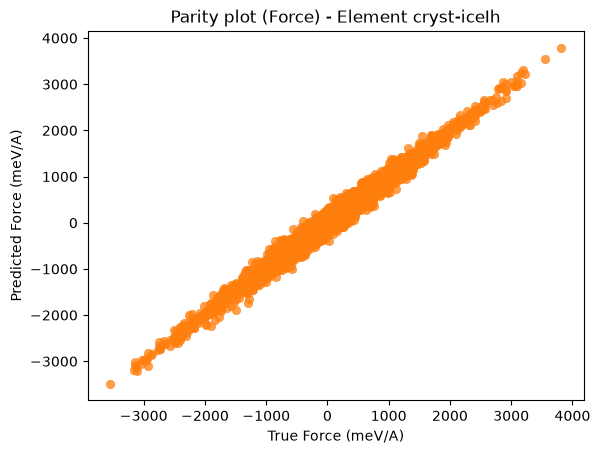

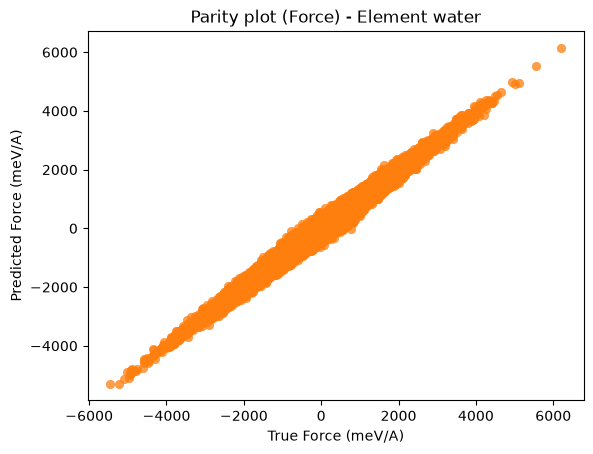

In [30]:
##PARITY PLOTS
colors = ['C0', 'C1']

#Bucle en los elementos
for elemento in array_elementos:
    array_elemento = array_force[array_force[:, 0] == elemento]
    x2=array_elemento[:, 2].astype(float)
    y2=array_elemento[:, 1].astype(float)


    plt.figure()
    plt.scatter(x2, y2, color=colors[1], alpha=0.75, linewidth=0.5)
    plt.xlabel("True Force (meV/A)")
    plt.ylabel("Predicted Force (meV/A)")
    plt.title(f"Parity plot (Force) - Element {elemento}")

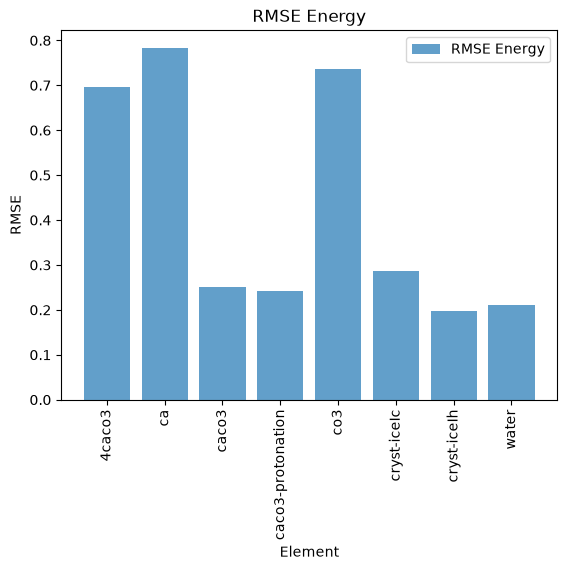

In [31]:
#Diagrama de barras: Energy
plt.figure()
plt.bar(array_elementos, rmse_energy_list, color='C0', label='RMSE Energy', alpha=0.7)
plt.xlabel('Element')
plt.ylabel('RMSE')
plt.legend()
plt.title('RMSE Energy')
plt.xticks(rotation='vertical')
plt.show()


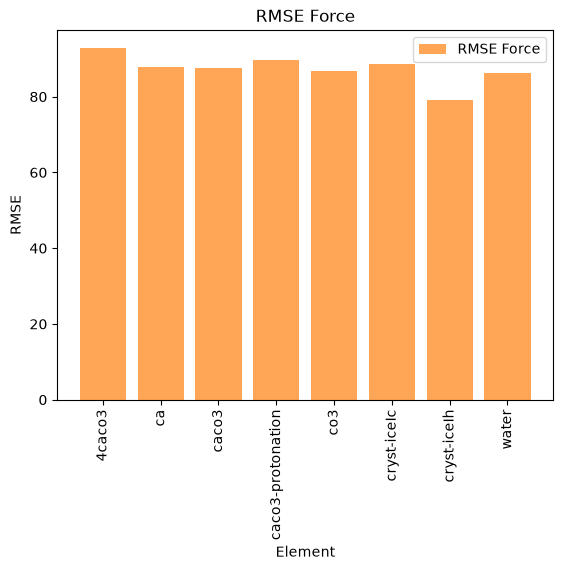

In [32]:
#diagrama de barras: RMSE Force
plt.figure()
plt.bar(array_elementos, rmse_force_list, color='C1', label='RMSE Force', alpha=0.7)
plt.xlabel('Element')
plt.ylabel('RMSE')
plt.legend()
plt.title('RMSE Force')
plt.xticks(rotation='vertical')
plt.show()

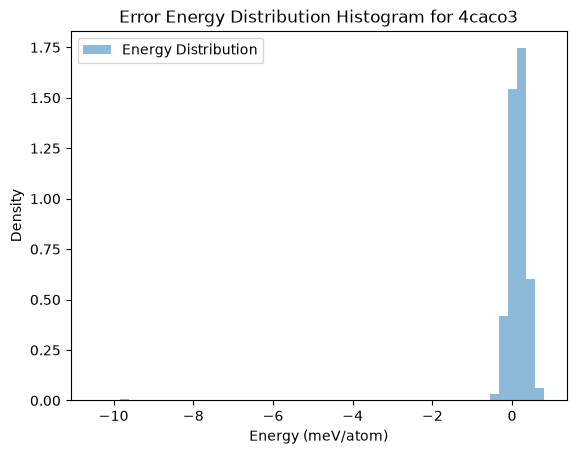

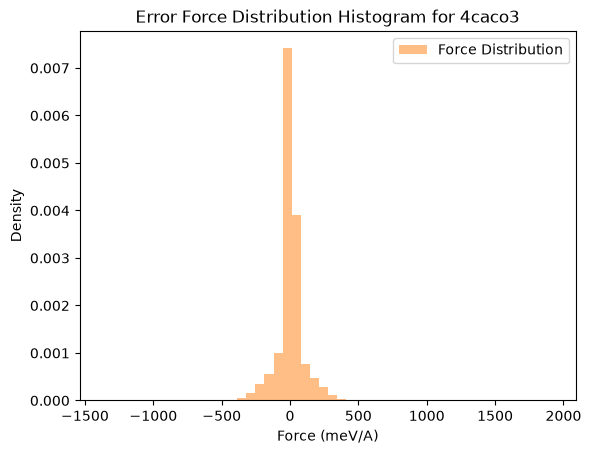

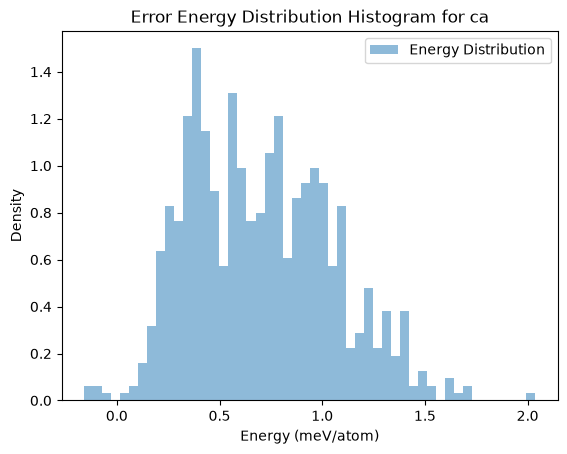

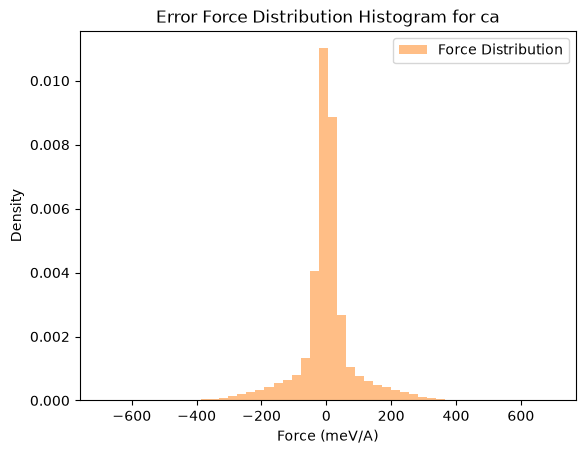

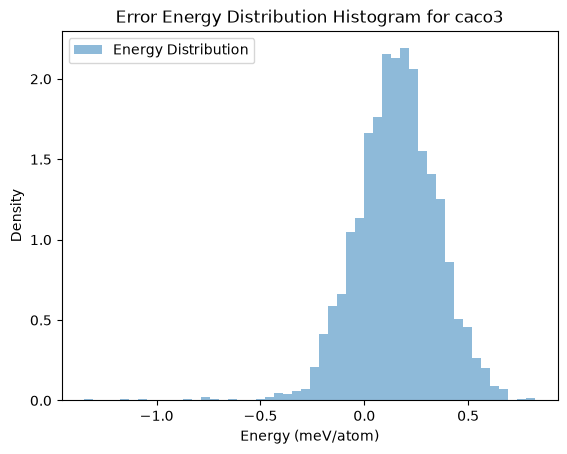

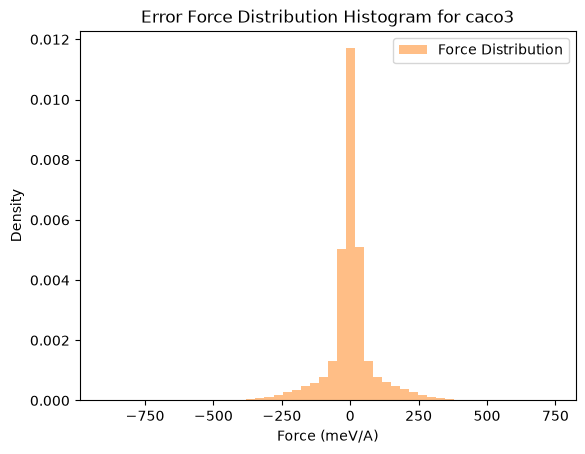

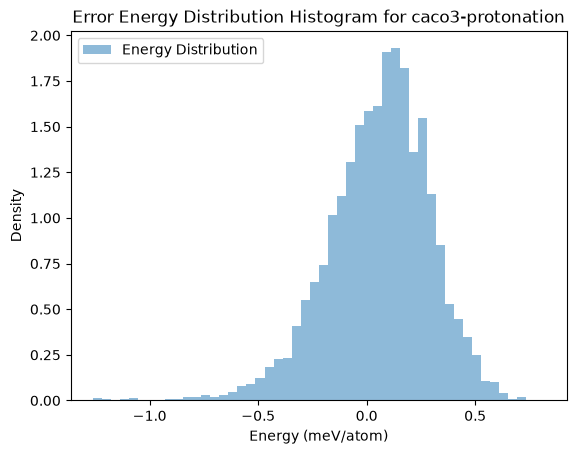

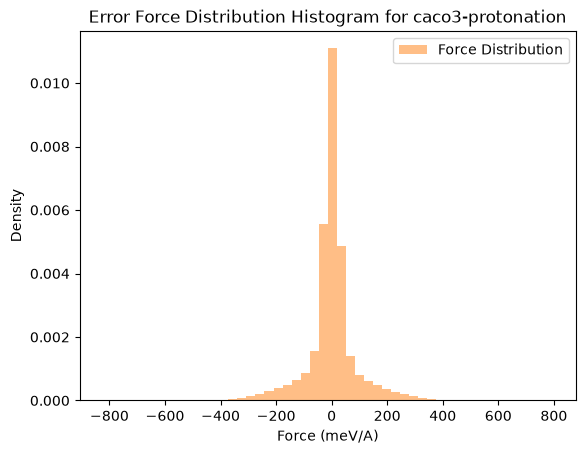

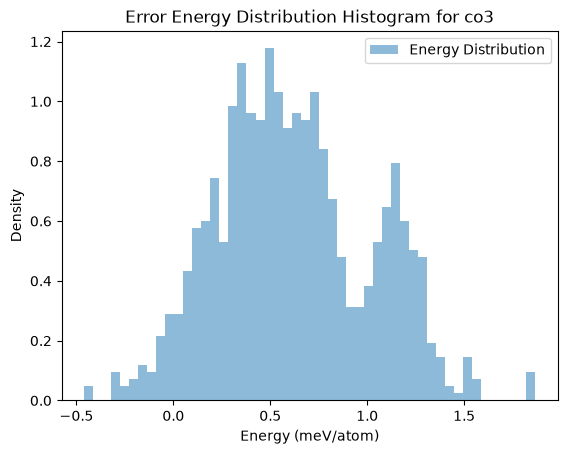

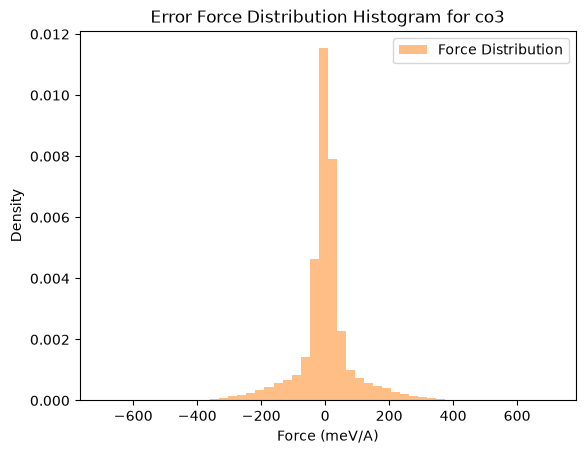

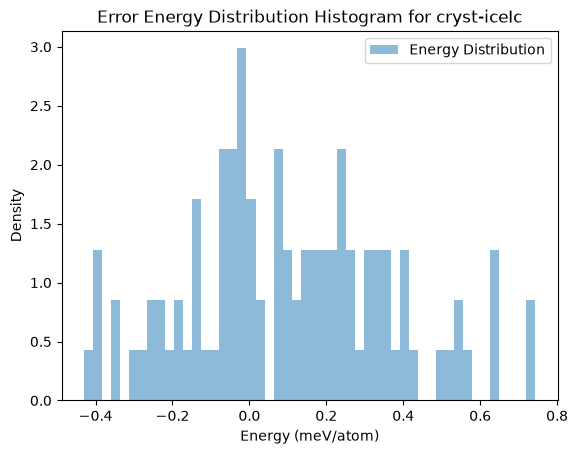

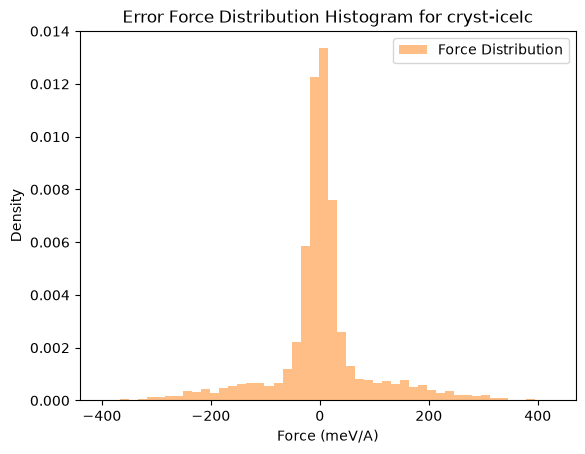

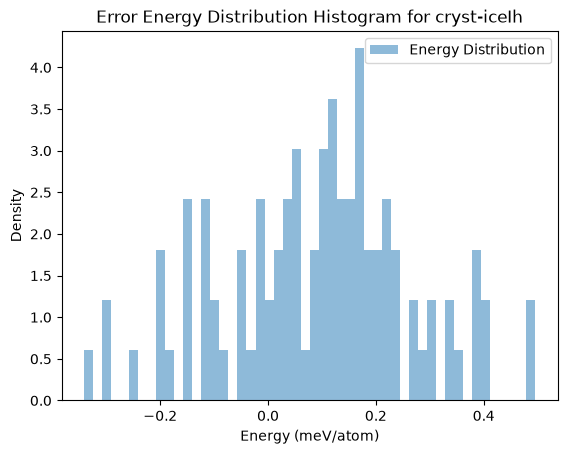

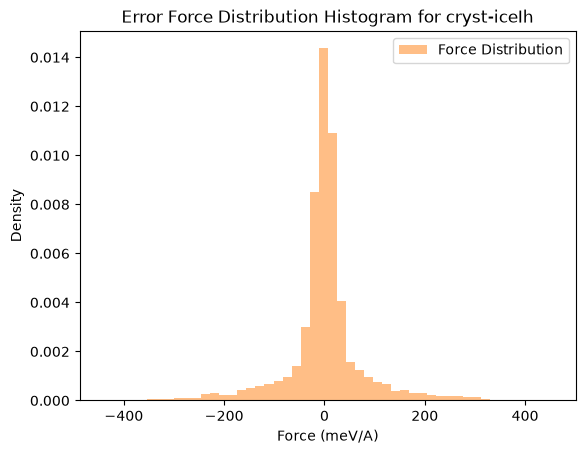

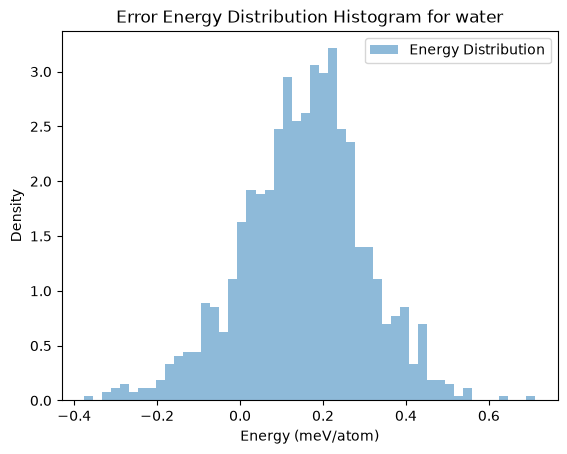

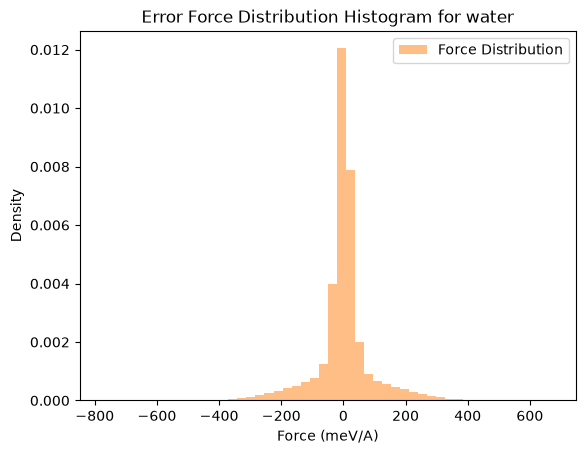

In [33]:
#histogramas error energy y error force
for elemento in array_elementos:
    array_elemento = array_energy[array_energy[:, 0] == elemento]
    x1=array_elemento[:, 2].astype(float)
    y1=array_elemento[:, 1].astype(float)

    error_energy = y1 - x1

    plt.figure()
    plt.hist(error_energy, bins=50, density=True, alpha=0.5, color='C0', label='Energy Distribution')
    plt.xlabel('Energy (meV/atom)')
    plt.ylabel('Density')
    plt.title(f"Error Energy Distribution Histogram for {elemento}")
    plt.legend()
    plt.show() 


    array_elemento = array_force[array_force[:, 0] == elemento]
    x2=array_elemento[:, 2].astype(float)
    y2=array_elemento[:, 1].astype(float)

    error_force = y2 - x2

    plt.figure()
    plt.hist(error_force, bins=50, density=True, alpha=0.5, color='C1', label='Force Distribution')
    plt.xlabel('Force (meV/A)')
    plt.ylabel('Density')
    plt.title(f"Error Force Distribution Histogram for {elemento}")
    plt.legend()
    plt.show() 

PARITY PLOTS JUNTO CON DISTRIBUCIONES DEL ERROR

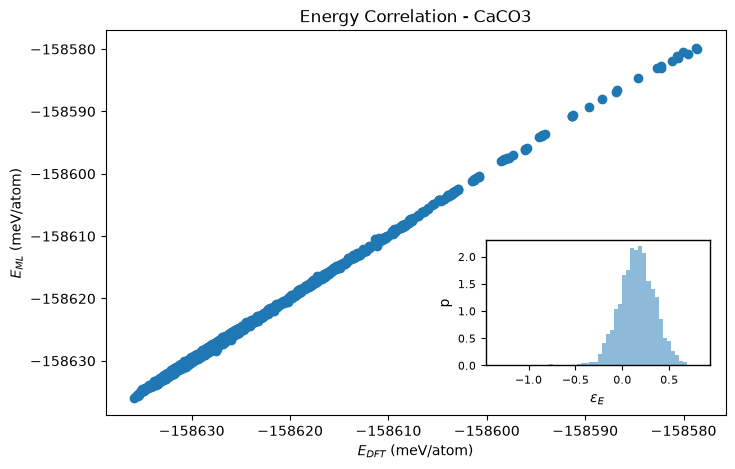

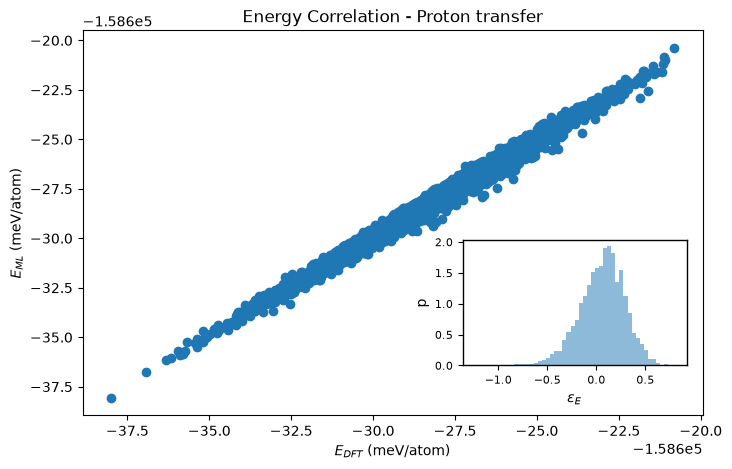

In [37]:
#caco3 y caco3 protonation
#Energía

colors = ['C0', 'C1']
rmse_energy_list = []
nuevo_array_elementos=['caco3', 'caco3-protonation']
for elemento in nuevo_array_elementos:
    array_elemento = array_energy[array_energy[:, 0] == elemento]
    x1=array_elemento[:, 2].astype(float)
    y1=array_elemento[:, 1].astype(float)

    #Calcular el RMSE para Energy
    rmse_energy = np.sqrt(np.mean(np.power(y1-x1,2)))
    rmse_energy_list.append(rmse_energy)
    error_energy = y1 - x1
    

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.scatter(x1, y1, color=colors[0])
    ax1.set_xlabel("$E_{DFT}$ (meV/atom)")
    ax1.set_ylabel("$E_{ML}$ (meV/atom)")
    if elemento == 'caco3':
        ax1.set_title(f"Energy Correlation - CaCO3")
    else:
        ax1.set_title(f"Energy Correlation - Proton transfer")
    

    # 2. Subgráfica (Inset) en la esquina inferior derecha
    # Ajustamos las coordenadas: [izquierda, abajo, ancho, alto]
    ax2 = fig.add_axes([0.60, 0.21, 0.28, 0.25]) 

    # Datos de la subgráfica
    ax2.hist(error_energy, bins=50, density=True, alpha=0.5, color='C0', label='Energy Distribution')
    ax2.set_xlabel('$\epsilon_E$')
    ax2.set_ylabel('p')

    # Ajustar el tamaño de los números en los ejes
    ax2.tick_params(axis='both', which='major', labelsize=8)

    # Opcional: Si quieres un marco bien definido alrededor de la subgráfica
    for spine in ax2.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')

    plt.show()

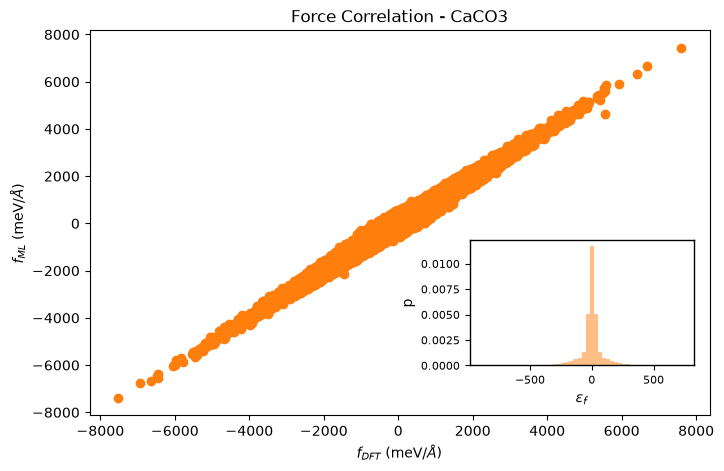

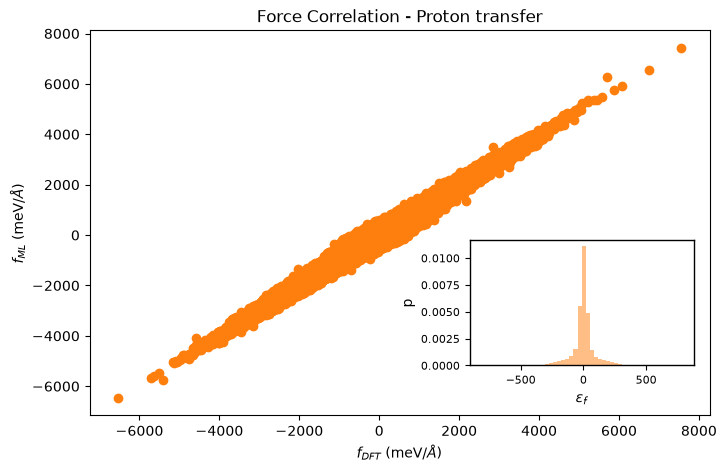

In [38]:
#caco3 y caco3 protonation
#Fuerza

colors = ['C0', 'C1']
rmse_force_list = []
nuevo_array_elementos=['caco3', 'caco3-protonation']
for elemento in nuevo_array_elementos:
    array_elemento = array_force[array_force[:, 0] == elemento]
    x2=array_elemento[:, 2].astype(float)
    y2=array_elemento[:, 1].astype(float)

    #Calcular el RMSE para Energy
    rmse_force = np.sqrt(np.mean(np.power(y1-x1,2)))
    rmse_force_list.append(rmse_energy)
    error_force = y2 - x2
    

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.scatter(x2, y2, color=colors[1])
    ax1.set_xlabel("$f_{DFT}$ (meV/$\AA$)")
    ax1.set_ylabel("$f_{ML}$ (meV/$\AA$)")

    if elemento == 'caco3':
        ax1.set_title(f"Force Correlation - CaCO3")
    else:
        ax1.set_title(f"Force Correlation - Proton transfer")

    # 2. Subgráfica (Inset) en la esquina inferior derecha
    # Ajustamos las coordenadas: [izquierda, abajo, ancho, alto]
    ax2 = fig.add_axes([0.60, 0.21, 0.28, 0.25]) 

    # Datos de la subgráfica
    ax2.hist(error_force, bins=50, density=True, alpha=0.5, color='C1', label='Energy Distribution')
    ax2.set_xlabel('$\epsilon_f$')
    ax2.set_ylabel('p')

    # Ajustar el tamaño de los números en los ejes
    ax2.tick_params(axis='both', which='major', labelsize=8)

    # Opcional: Si quieres un marco bien definido alrededor de la subgráfica
    for spine in ax2.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')

    plt.show()